# Outline

1. Feature Engineering
    1. Load Data
    2. Clean Data
    3. Create TFIDF Vectors
    4. Flesch Reading Ease Score
2. Modeling
3. Model Refinement and Hyperparameter Tuning
4. Generate Final Training Dataset


# Feature Engineering

In [1]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

import textstat
from utils import clean_text
from wordcloud import WordCloud

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\E083660\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 1. Load the Dataset

In [8]:
# Load the dataset
dataset = pd.read_csv('data/processed_combined_data.csv', usecols=[0,1,2,3,4,5,6,7,8,9])

# Work with a sample for prototyping
dataset = dataset.sample(n=1000, random_state=24)
dataset.head()

C:\Users\E083660\AppData\Local\Temp\ipykernel_40128\3277353793.py:2: DtypeWarning: Columns (0,1,2,4,5,6,7,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv('data/processed_combined_data.csv', usecols=[0,1,2,3,4,5,6,7,8,9])


,Unnamed: 0,label,author,text,date,dataset,type,title,subject,extracted_source
9745,9745,2,Patty Judge,"When a bill is sent to the governors office, t...",6/1/16,1,statement,NaN,NaN,NaN
60584,61193,0,NaN,Says Greg Abbott converted over 1 million in f...,NaN,2,statement,NaN,"crime,criminal-justice,elections,legal-issues",NaN
113662,114469,0,NaN,Donald Trump has absolutely no evidence that P...,NaN,4,article,WATCH: Former Director Of National Intelligen...,NaN,NaN
53155,53145,0,NaN,source infowars vote fraud expert bev harris e...,NaN,4,NaN,why hillary clintons campaign is collapsing t...,NaN,NaN
77428,78257,4,NaN,HARARE Reuters - Zimbabwe President Robert Mug...,NaN,3,article,Zimbabwe's Mugabe speech was meant to sanitize...,worldnews,Reuters


## 2. Clean Data

In [10]:
# Drop rows where 'text' is missing
dataset_tokenized = dataset[dataset['text'].notnull()].copy()

# Optional: Preprocess text (e.g., lowercasing, remove numbers, punctuation, extra whitespace, and tokenize)
dataset_tokenized[['cleaned_text', 'text_tokenized']] = dataset_tokenized['text'].apply(lambda x: pd.Series(clean_text(x)))


In [11]:
dataset_tokenized.head()

,Unnamed: 0,label,author,text,date,dataset,type,title,subject,extracted_source,cleaned_text,text_tokenized
9745,9745,2,Patty Judge,"When a bill is sent to the governors office, t...",6/1/16,1,statement,NaN,NaN,NaN,when a bill is sent to the governors office th...,"[when, a, bill, is, sent, to, the, governors, ..."
60584,61193,0,NaN,Says Greg Abbott converted over 1 million in f...,NaN,2,statement,NaN,"crime,criminal-justice,elections,legal-issues",NaN,says greg abbott converted over million in fed...,"[says, greg, abbott, converted, over, million,..."
113662,114469,0,NaN,Donald Trump has absolutely no evidence that P...,NaN,4,article,WATCH: Former Director Of National Intelligen...,NaN,NaN,donald trump has absolutely no evidence that p...,"[donald, trump, has, absolutely, no, evidence,..."
53155,53145,0,NaN,source infowars vote fraud expert bev harris e...,NaN,4,NaN,why hillary clintons campaign is collapsing t...,NaN,NaN,source infowars vote fraud expert bev harris e...,"[source, infowars, vote, fraud, expert, bev, h..."
77428,78257,4,NaN,HARARE Reuters - Zimbabwe President Robert Mug...,NaN,3,article,Zimbabwe's Mugabe speech was meant to sanitize...,worldnews,Reuters,harare reuters zimbabwe president robert mugab...,"[harare, reuters, zimbabwe, president, robert,..."


In [6]:
dataset_tokenized['label'].unique()

array([2, 0, '0', 4, '4', 1, 3, '2', '1', '3',
       ' while criticizing their conservative counterparts.National Committee for Voting Integrity This group opposes  the implementation of proof of citizenship and photo identification requirements for eligible electors in American elections as the means of assuring election integrity. National Council for Research on Women This group supports big government',
       ' like the fraudulent story published in The Post'], dtype=object)

## 3. Create TF-IDF Vectors

In [9]:
#########
# CREATE - TFIDF vectors
#########

# Initialize the TF-Idataset Vectorizer with a maximum number of features and English stopwords removal
tfidf_vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')

# Fit and transform the cleaned text into a TF-Idataset feature matrix
tfidf_matrix = tfidf_vectorizer.fit_transform(dataset_tokenized['cleaned_text'])

# Convert the TF-Idataset matrix to a DataFrame for inspection or further processing
tfidf_dataset = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Bring back some of the original columns for reference
tfidf_df = pd.concat([dataset_tokenized[['Unnamed: 0', 'label', 'text', 'cleaned_text']].reset_index(drop=True), tfidf_dataset], axis=1)

# Display the first few rows of the TF-Idataset features
print(tfidf_df.head())

tfidf_df.describe()


  Unnamed: 0 label                                               text  \
0       9745     2  When a bill is sent to the governors office, t...   
1      61193     0  Says Greg Abbott converted over 1 million in f...   
2     114469     0  Donald Trump has absolutely no evidence that P...   
3      53145     0  source infowars vote fraud expert bev harris e...   
4      78257     4  HARARE Reuters - Zimbabwe President Robert Mug...   

                                        cleaned_text  ability  able  abortion  \
0  when a bill is sent to the governors office th...      0.0   0.0       0.0   
1  says greg abbott converted over million in fed...      0.0   0.0       0.0   
2  donald trump has absolutely no evidence that p...      0.0   0.0       0.0   
3  source infowars vote fraud expert bev harris e...      0.0   0.0       0.0   
4  harare reuters zimbabwe president robert mugab...      0.0   0.0       0.0   

   absolutely  access  according  ...  worst  wrong  wrote   xi  year  \
0

,ability,able,abortion,absolutely,access,according,account,accused,act,action,...,worst,wrong,wrote,xi,year,yearold,years,yes,york,young
count,9986.000000,9986.000000,9986.000000,9986.000000,9986.000000,9986.000000,9986.000000,9986.000000,9986.000000,9986.000000,...,9986.000000,9986.000000,9986.000000,9986.000000,9986.000000,9986.000000,9986.000000,9986.000000,9986.000000,9986.000000
mean,0.002563,0.004654,0.003900,0.002697,0.004143,0.009975,0.003417,0.004758,0.006672,0.004387,...,0.002792,0.003379,0.004737,0.002356,0.015940,0.004531,0.015090,0.002926,0.008656,0.004444
std,0.021099,0.023971,0.042997,0.017129,0.028373,0.029835,0.025128,0.022890,0.034145,0.021507,...,0.023995,0.022821,0.024374,0.029522,0.049063,0.024655,0.046294,0.021522,0.036081,0.028048
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,0.532360,1.000000,0.408664,0.617688,0.327667,0.634285,0.422815,0.682630,0.402542,...,0.936590,0.595674,0.575924,0.743830,1.000000,0.686463,0.606247,0.699130,0.625789,0.647814


## 4. Flesch Reading Ease Score

In [10]:
# Compute the Flesch Reading Ease score for each document
dataset_flesch = dataset_tokenized.copy()
dataset_flesch['flesch_reading_ease'] = dataset_flesch['text'].apply(textstat.flesch_reading_ease)

# (Optional) Inspect the computed scores
print(dataset_flesch[['cleaned_text', 'flesch_reading_ease']].head())

                                             cleaned_text  flesch_reading_ease
9745    when a bill is sent to the governors office th...                74.90
60584   says greg abbott converted over million in fed...                 9.90
113662  donald trump has absolutely no evidence that p...                44.64
53155   source infowars vote fraud expert bev harris e...               -64.54
77428   harare reuters zimbabwe president robert mugab...                57.10


## Combine and Output csv

In [11]:
final_df = tfidf_df.copy()

# Add the Flesch Reading Ease scores to the TF-Idataset DataFrame
final_df['flesch_reading_ease'] = dataset_flesch['flesch_reading_ease'].values

# Save the final dataset to a CSV file
datetime = pd.Timestamp.now().strftime('%Y%m%d%H')
final_df.to_csv(f'data/final_dataset_{datetime}.csv', index=False)

# 5. Initial Modeling

In [12]:
# Load your dataset (update the file path as needed)
data = pd.read_csv(f"data/final_dataset_2025032418.csv", low_memory=False)

In [13]:
data.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9986 entries, 0 to 9985
Data columns (total 1005 columns):
 #     Column               Dtype  
---    ------               -----  
 0     Unnamed: 0           object 
 1     label                object 
 2     text                 object 
 3     cleaned_text         object 
 4     ability              float64
 5     able                 float64
 6     abortion             float64
 7     absolutely           float64
 8     access               float64
 9     according            float64
 10    account              float64
 11    accused              float64
 12    act                  float64
 13    action               float64
 14    actions              float64
 15    actually             float64
 16    added                float64
 17    adding               float64
 18    address              float64
 19    administration       float64
 20    adviser              float64
 21    afghanistan          float64
 22    agencies            

In [ ]:
# Load your dataset (update the file path as needed)
data = pd.read_csv(f"data/final_dataset_2025032418.csv", low_memory=False)

# Convert the target column to numeric, setting invalid parsing as NaN
# Effectively this gets rid of rows where the target column is not numeric
# In some cases the target column was text from the article, or other invalid data
data['label'] = pd.to_numeric(data['label'], errors='coerce')

# Drop rows where the conversion failed (i.e., where target_numeric is NaN)
data = data.dropna(subset=['label'])

# Cast the target column back to a string for classifcation
data['label'] = data['label'].astype(str)

# Separate features and target
X = data.iloc[:, 4:]
y = data["label"]

# Split the data into training and testing sets using stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=24, stratify=y
)

# Define a dictionary of candidate classifiers
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=24),
    "Random Forest": RandomForestClassifier(random_state=24),
    "Gradient Boosting": GradientBoostingClassifier(random_state=24),
    "Support Vector Classifier": SVC(probability=True, random_state=24),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

# Evaluate each model using 5-fold cross-validation on the training set
cv_results = {}
print("Cross-Validation Accuracy Scores:")
for name, model in models.items():
    # Using accuracy as the scoring metric; you can switch to "f1_weighted" if desired.
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    cv_results[name] = scores.mean()
    print(f"{name}: {scores.mean():.4f}")

# Determine the best model based on cross-validation performance
best_model_name = max(cv_results, key=cv_results.get)
best_model = models[best_model_name]
print(f"\nBest model based on cross-validation: {best_model_name}")

# Train the best model on the entire training set
best_model.fit(X_train, y_train)

# Make predictions on the test set
predictions = best_model.predict(X_test)

# Evaluate performance on the test set
test_accuracy = accuracy_score(y_test, predictions)
test_f1 = f1_score(y_test, predictions, average="weighted")
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")

Cross-Validation Accuracy Scores:


c:\Cloned Repos\TruthFinder\venv\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Cloned Repos\TruthFinder\venv\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regr

Logistic Regression: 0.7988
Random Forest: 0.8203
Gradient Boosting: 0.8161
Support Vector Classifier: 0.5693
K-Nearest Neighbors: 0.6745

Best model based on cross-validation: Random Forest

Test Accuracy: 0.8252
Test F1 Score: 0.8007


## 1. EDA

In [ ]:
# Load the combined sample dataset
eda_df = pd.read_csv('data/combined_data_sample.csv')

In [22]:
# Preview the first few rows
print(eda_df.head())

# Get a summary of the dataframe structure and data types
print(eda_df.info())

# Summary statistics for numeric columns
print(eda_df.describe())

# Check for missing values
missing = eda_df.isnull().sum()
print("Missing values per column:\n", missing[missing > 0])


   Unnamed: 0  label                                               text  \
0           2      3  Says Maggie Hassan was out of state on 30 days...   
1          71      1  Ted Cruz is unknown to the vast majority of Te...   
2         104      1  Gas prices have gone up 99 percent since Obama...   
3         139      0  At least 10 ISIS fighters have been caught com...   
4         182      3  Gas in North Carolina increased 14 cents per g...   

        type  Polarity  Subjectivity  avg_polarity  avg_subjectivity  \
0  statement  0.000000      0.066667      0.000000          0.066667   
1  statement -0.050000      0.800000     -0.050000          0.800000   
2  statement  0.000000      0.000000      0.000000          0.000000   
3  statement  0.066667      0.300000      0.066667          0.300000   
4  statement -0.250000      0.250000     -0.250000          0.250000   

   num_quotes                                       cleaned_text  ...  wrong  \
0           2  says maggie hassan wa

### Categorical Variables

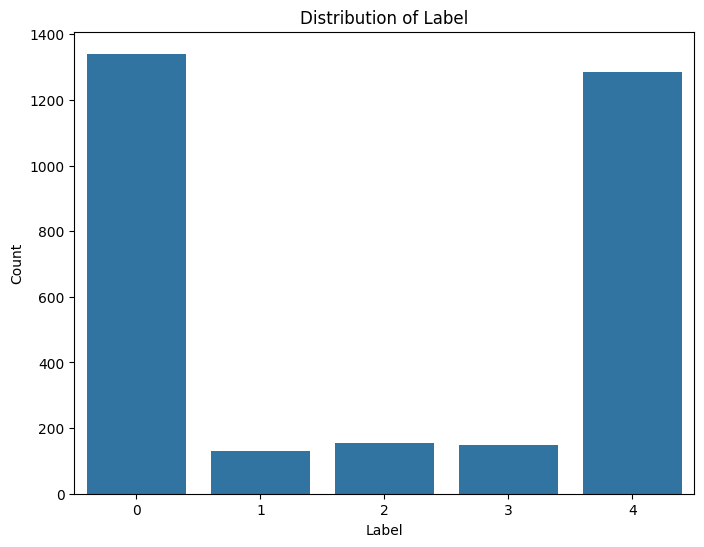

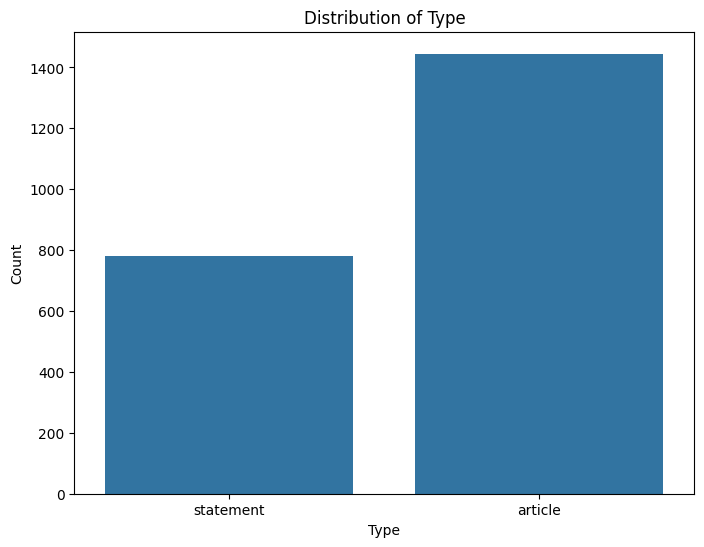

In [27]:
# Count plot for the 'label' column
plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=eda_df)
plt.title("Distribution of Label")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

# Count plot for the 'type' column (if applicable)
plt.figure(figsize=(8, 6))
sns.countplot(x='type', data=eda_df)
plt.title("Distribution of Type")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

### Numerical Features

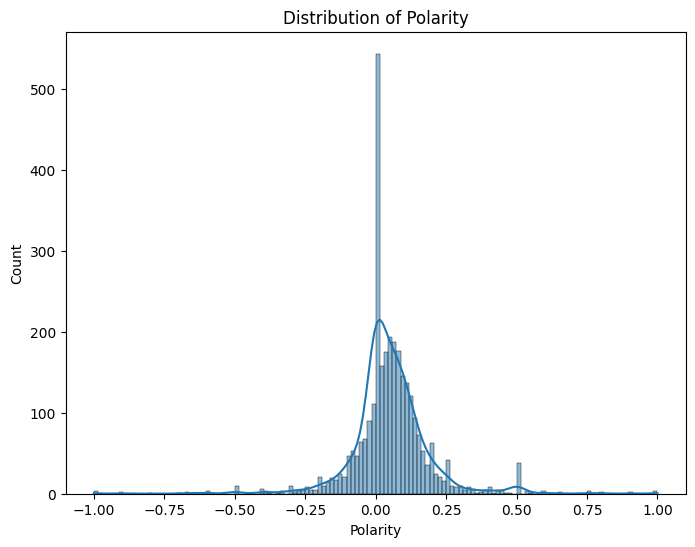

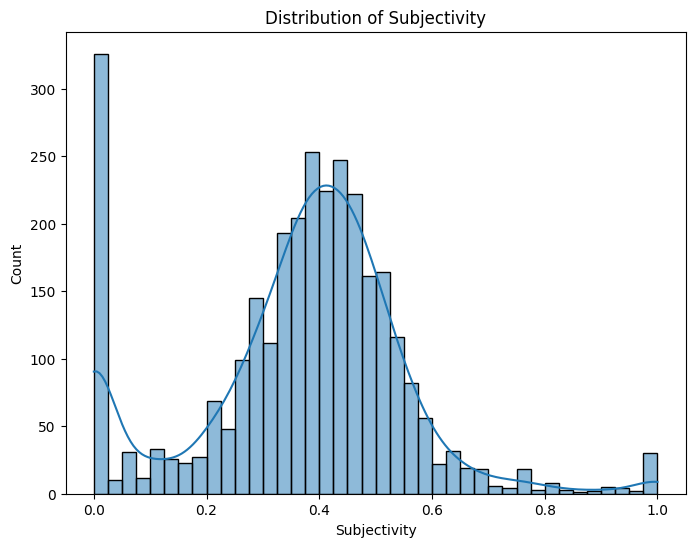

KeyboardInterrupt: 

Error in callback <function flush_figures at 0x000002BB8834D510> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [ ]:
# Histogram and KDE for Polarity
plt.figure(figsize=(8, 6))
sns.histplot(eda_df['Polarity'], kde=True)
plt.title("Distribution of Polarity")
plt.xlabel("Polarity")
plt.show()

# Histogram and KDE for Subjectivity 
# TODO - Check out avg subjectivity score and look into the massive 0 values
plt.figure(figsize=(8, 6))
sns.histplot(eda_df['Subjectivity'], kde=True)
plt.title("Distribution of Subjectivity")
plt.xlabel("Subjectivity")
plt.show()

# Correlation Heatmap for numeric features
# Dimensionality Reduction needs to be performed before plotting the heatmap
# plt.figure(figsize=(12, 10))
# numeric_cols = eda_df.select_dtypes(include=['int64', 'float64']).columns
# corr = eda_df[numeric_cols].corr()
# sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
# plt.title("Correlation Heatmap of Numeric Features")
# plt.show()


### Word Cloud

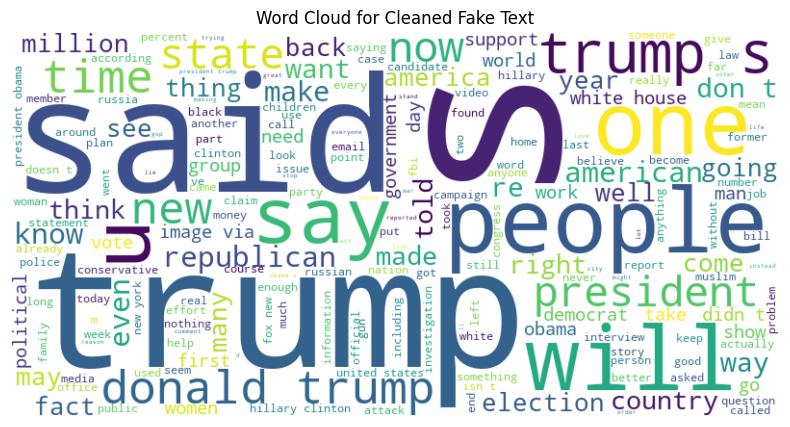

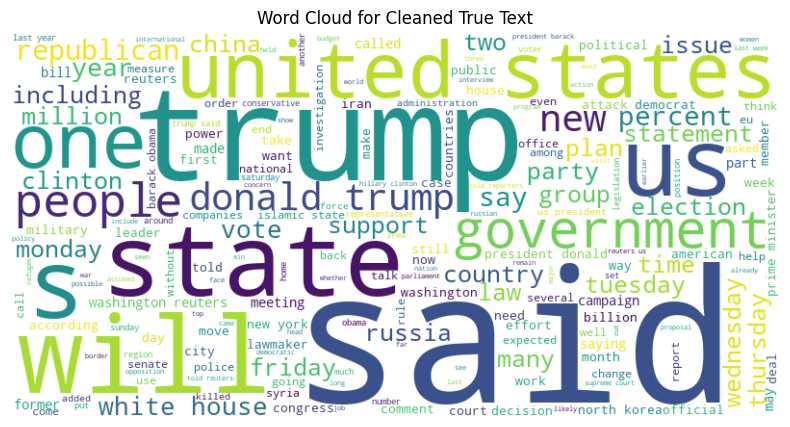

In [33]:
# Filter to select fake news articles or true news articles
df_fake = eda_df[(eda_df['label'] == 1) | (eda_df['label'] == 0)]
df_true = eda_df[(eda_df['label'] == 3) | (eda_df['label'] == 4)]
# Generate a word cloud from the cleaned_text column of the fake dataset 
text_combined = " ".join(df_fake["cleaned_text"].dropna())
fake_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_combined)

plt.figure(figsize=(10, 5))
plt.imshow(fake_wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Cleaned Fake Text")
plt.show()

# Generate a word cloud from the cleaned_text column of the true dataset
text_combined = " ".join(df_true["cleaned_text"].dropna())
true_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_combined)

plt.figure(figsize=(10, 5))
plt.imshow(true_wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Cleaned True Text")
plt.show()


# Model Refinement and Tuning

In [ ]:
# Load the dataset
adv_df = pd.read_csv('data/final_dataset_with_pca.csv')

# Create x and y variables
X = adv_df.drop(columns=['Unnamed: 0', 'label', 'text', 'type', 'cleaned_text'])
y = adv_df['label']

# Split the data into training and testing sets using stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=24, stratify=y
)

## LR

In [52]:
# Assuming X_train and y_train are already defined
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(solver='lbfgs', max_iter=1000, random_state=24))
])

param_grid_lr = {
    'lr__C': [0.01, 0.1, 1, 10, 100]
    # lbfgs supports only L2 penalty; if you change solver, you can try others.
}

grid_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X_train, y_train)

print("Best parameters (Logistic Regression):", grid_lr.best_params_)
print("Best CV score (Logistic Regression):", grid_lr.best_score_)


Best parameters (Logistic Regression): {'lr__C': 0.01}
Best CV score (Logistic Regression): 0.7773615458453319


## RF

In [53]:
rf = RandomForestClassifier(random_state=24)

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Best parameters (Random Forest):", grid_rf.best_params_)
print("Best CV score (Random Forest):", grid_rf.best_score_)

Best parameters (Random Forest): {'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score (Random Forest): 0.8145453027836901


# Generate Final Dataset

In [118]:
from utils import extract_features_from_article
# Load the dataset
final_df = pd.read_csv('data/processed_combined_data.csv', usecols=[0,1,3])
# Filter out rows where the 'text' column is not a string
final_df = final_df[final_df['text'].apply(lambda x: isinstance(x, str))]
# final_df = final_df.reset_index(drop=True)
final_df.head()

C:\Users\E083660\AppData\Local\Temp\ipykernel_28788\3701140687.py:3: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  final_df = pd.read_csv('data/processed_combined_data.csv', usecols=[0,1,3])


,Unnamed: 0,label,text
0,0,4,John McCain opposed bankruptcy protections for...
1,1,0,Bennie Thompson actively cheer-led riots in th...
2,2,3,Says Maggie Hassan was out of state on 30 days...
3,3,0,"BUSTED CDC Inflated COVID Numbers, Accused of ..."
4,4,2,Im the only Republican candidate that has actu...


### Clean the dataset

In [119]:
## Fix the label column
# Convert labels to numeric; non-numeric entries become NaN
final_df['label_numeric'] = pd.to_numeric(final_df['label'], errors='coerce')

# Keep only rows where the numeric label is one of [0, 1, 2, 3, 4]
final_df = final_df[final_df['label_numeric'].isin([0, 1, 2, 3, 4])].copy()

# Convert to integer type
final_df['label_numeric'] = final_df['label_numeric'].astype(int)

# Optionally, drop the old label column and rename the new one:
final_df.drop(columns=['label'], inplace=True)
final_df.rename(columns={'label_numeric': 'label'}, inplace=True)


# Investigate the rows where cleaned_text is empty

# # Find rows where cleaned_text is empty (after stripping any whitespace)
# empty_cleaned_text = final_df[final_df['cleaned_text'].str.strip() == '']

# # Inspect these rows: you might want to look at the original 'text' too
# print(empty_cleaned_text[['Unnamed: 0', 'text', 'cleaned_text']])

# In this case it turns out that there were 636 rows where the original text field was empty, so that data is unusable and should be dropped
final_df = final_df[final_df['text'].str.strip() != '']


#### Final sanity checks that data looks decent

In [120]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 115268 entries, 0 to 116069
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  115268 non-null  object
 1   text        115268 non-null  object
 2   label       115268 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 3.5+ MB


In [121]:
final_df['label'].unique()

array([4, 0, 3, 2, 1])

### Creating all features besides TF-IDF

#### This next code cell took me about 19 minutes to run, and I exported the results to a csv so it shouldn't need to be run again, if you need the results feel free to reach out.

/# Extract features from the 'text' column using the provided function from utils
<br>
final_df['features'] = final_df['text'].apply(extract_features_from_article)

### TF-IDF Feature Creation and Dimensionality Reduction

In [122]:
final_df['cleaned_text'] = final_df['text'].apply(lambda x: clean_text(x, lower_text=True, remove_whitespace=True, fix_encoding=True, tokenize=False)[0])

In [124]:
## Right here we'll check and see if the cleaning function obliterated the text completely
# Check for empty cleaned_text after cleaning
empty_cleaned_text = final_df[final_df['cleaned_text'].str.strip() == '']
# Inspect these rows: you might want to look at the original 'text' too
print(empty_cleaned_text[['Unnamed: 0', 'text', 'cleaned_text']])

Empty DataFrame
Columns: [Unnamed: 0, text, cleaned_text]
Index: []


In [127]:
from sklearn.decomposition import PCA
from utils import clean_text

# --- TF-IDF feature creation ---
# Assume 'dataset_tokenized' is your DataFrame with a 'cleaned_text' column.
tfidf_vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(final_df['cleaned_text'])

# Convert the TF-IDF matrix to a DataFrame
tfidf_dataset = pd.DataFrame(tfidf_matrix.toarray(), 
                             columns=tfidf_vectorizer.get_feature_names_out())

# --- PCA on TF-IDF features ---
# Initialize PCA to keep the top 5 components
pca = PCA(n_components=50)
tfidf_pca = pca.fit_transform(tfidf_dataset)

# Create a DataFrame with PCA features
tfidf_pca_df = pd.DataFrame(tfidf_pca, columns=[f'pca_{i+1}' for i in range(50)])

# Optionally, inspect variance explained by the components
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Cumulative Variance:", pca.explained_variance_ratio_.sum())

# Combine PCA features with key columns from the original dataset
final_df_50pca = pd.concat(
    [final_df[['Unnamed: 0', 'label', 'text']].reset_index(drop=True),
    tfidf_pca_df.reset_index(drop=True)],
    axis=1
)

# Now, final_df contains the top 5 PCA components along with your reference columns.
print(final_df_50pca.head())


Explained Variance Ratio: [0.02189632 0.0149801  0.01058244 0.01018515 0.00928817 0.00829739
 0.0077529  0.00719991 0.0069798  0.00659218 0.00628592 0.00614694
 0.0058068  0.00562769 0.00541956 0.00501731 0.00487337 0.00470167
 0.00453055 0.00435062 0.0042566  0.00423329 0.00400406 0.00395141
 0.00380761 0.00377777 0.00366368 0.00363876 0.00352293 0.00347543
 0.00340387 0.00334522 0.00331238 0.00330025 0.00324485 0.00321175
 0.00318126 0.00316038 0.00306461 0.00302672 0.00297654 0.00297424
 0.00292485 0.00290826 0.00283993 0.0028244  0.0027673  0.00275621
 0.00270932 0.00268702]
Cumulative Variance: 0.2554657051181389
  Unnamed: 0  label                                               text  \
0          0      4  John McCain opposed bankruptcy protections for...   
1          1      0  Bennie Thompson actively cheer-led riots in th...   
2          2      3  Says Maggie Hassan was out of state on 30 days...   
3          3      0  BUSTED CDC Inflated COVID Numbers, Accused of ...   
4   

## Export Final DF

Merge the tf-idf features with the rest of the features into one final master df

In [128]:
# Load all the other features
other_features = pd.read_csv('data/processed_combined_data_with_features_no_tfidf.csv')

In [129]:
# Make sure the Unnamed: 0 column is of type string and stripped of whitespace in both DataFrames
final_df_50pca['Unnamed: 0'] = final_df_50pca['Unnamed: 0'].astype(str).str.strip()
other_features['Unnamed: 0'] = other_features['Unnamed: 0'].astype(str).str.strip()

In [ ]:
# Unique key check
# This discrepancy tracks because there were a 636 rows with missing text in the dataset used to compute 
# the other features, but these rows were dropped as well as some additional rows before I created the tfidf features
keys_left = set(final_df_50pca['Unnamed: 0'].unique())
keys_right = set(other_features['Unnamed: 0'].unique())
print("Keys in left only:", keys_left - keys_right)
print("Keys in right only:", keys_right - keys_left)


Keys in left only: set()
Keys in right only: {'104799', '96504', '105044', '97110', '101529', '97631', '97620', '107106', '104918', '97737', '104525', '104920', '104772', '97367', '97213', '104259', '104837', '97168', '105142', '105026', '98287', '96916', '100989', '107105', '97934', '104787', '96811', '97689', '98753', '96967', '97082', '96922', '97960', '96860', '96971', '96842', '97512', '97275', '98309', '97753', '101686', '96997', '98359', '97423', '96904', '104913', '104641', '104265', '105030', '101597', '101007', '96622', '101538', '97163', '104195', '104397', '97563', '97290', '98218', '97575', '97056', '101457', '98180', '97396', '104887', '101514', '97910', '97938', '97549', '105062', '104544', '96799', '98150', '96582', '96689', '101064', '96613', '97179', '98077', '97547', '96614', '96694', '97440', '96609', '96838', '97435', '98118', '97977', '102549', '97153', '97388', '96784', '97866', '97193', '98296', '97664', '105085', '97752', '104929', '100988', '102634', '97615', 

In [132]:
print(final_df_50pca['Unnamed: 0'].isnull().sum())
print(other_features['Unnamed: 0'].isnull().sum())


0
0


In [134]:
# print(final_df_50pca['Unnamed: 0'].duplicated().sum(), "duplicates in final_df_50pca")
# print(other_features['Unnamed: 0'].duplicated().sum(), "duplicates in other_features")

# final_df_50pca[final_df_50pca['Unnamed: 0'].duplicated(keep=False)].head(10) # View the duplicates in the final_df_50pca DataFrame
# other_features[other_features['Unnamed: 0'].duplicated(keep=False)].head(10) # View duplicates in the other_features DataFrame

# Since the duplicates are the same and unusable for training, we can drop them from both DataFrames
final_df_50pca = final_df_50pca.drop_duplicates(subset='Unnamed: 0')
other_features = other_features.drop_duplicates(subset='Unnamed: 0')

In [138]:
# We'll execute a left join here because I applied stricter data cleansing to the final_df_50pca DataFrame
final_df = pd.merge(
    final_df_50pca, 
    other_features[['Unnamed: 0', 'features', 'text']], 
    left_on='Unnamed: 0', 
    right_on='Unnamed: 0', 
    how='left', 
    validate='1:1'
)
final_df = final_df[['Unnamed: 0', 'label', 'text_x' ,'text_y', 'features'] + [f'pca_{i+1}' for i in range(50)]]

Originally, I kept text from both datasets to ensure the records matched, however we don't actually need that in the final dataset so I will remove. 

In [140]:
final_df = final_df[['Unnamed: 0', 'label', 'text_x', 'features'] + [f'pca_{i+1}' for i in range(50)]].rename(columns={'text_x': 'text'})

In [141]:
final_df.to_csv('data/final_dataset_with_pca.csv', index=False)

# Exporting the fitted tfidf_vectorizer and the fitted pca model for future reference

In [142]:
import joblib

# Save the fitted vectorizer and PCA model to disk
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.joblib')
joblib.dump(pca, 'pca_model.joblib')

# Later, load them back for use in predictions
tfidf_vectorizer = joblib.load('tfidf_vectorizer.joblib')
pca = joblib.load('pca_model.joblib')

# Final Model Training

In [158]:
final_model_df = pd.read_csv('data/final_dataset_with_pca.csv', low_memory=False)

In [ ]:
# Expand the features column into individual columns
import ast
# Convert string representations of dictionaries into actual dictionaries
final_model_df['features'] = final_model_df['features'].apply(ast.literal_eval)

# Create a new DataFrame from the dictionary column
features_df = pd.DataFrame(final_model_df['features'].tolist())

# Concatenate it with the original DataFrame
final_model_df = pd.concat([final_model_df, features_df], axis=1)
final_model_df.head()


,Unnamed: 0,label,text,features,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,...,pca_48,pca_49,pca_50,flesch_reading_ease,word_count,overall_polarity,overall_subjectivity,avg_sentence_polarity,avg_sentence_subjectivity,num_speech_attributes
0,0,4,John McCain opposed bankruptcy protections for...,"{'flesch_reading_ease': 26.81, 'word_count': 1...",-0.120083,-0.098241,-0.007411,0.028325,-0.004144,-0.021404,...,0.059016,-0.003829,0.053748,26.81,19,0.000000,0.500000,0.000000,0.500000,0
1,1,0,Bennie Thompson actively cheer-led riots in th...,"{'flesch_reading_ease': 63.36, 'word_count': 8...",-0.125474,-0.056743,-0.029588,-0.000564,0.014635,-0.012085,...,-0.014961,0.010465,-0.011454,63.36,8,-0.133333,0.600000,-0.133333,0.600000,0
2,2,3,Says Maggie Hassan was out of state on 30 days...,"{'flesch_reading_ease': 90.09, 'word_count': 1...",-0.176225,-0.155424,-0.077049,0.085559,0.145983,0.138020,...,-0.037983,0.035203,0.003913,90.09,15,0.000000,0.066667,0.000000,0.066667,1
3,3,0,"BUSTED CDC Inflated COVID Numbers, Accused of ...","{'flesch_reading_ease': 10.56, 'word_count': 1...",-0.124194,-0.059147,0.028516,0.001280,-0.024788,0.029170,...,0.048162,0.015755,-0.136216,10.56,10,0.000000,0.000000,0.000000,0.000000,0
4,4,2,Im the only Republican candidate that has actu...,"{'flesch_reading_ease': 32.9, 'word_count': 13...",-0.049912,-0.048520,0.090457,0.019727,-0.001077,-0.021409,...,-0.004625,-0.044777,-0.017304,32.90,13,0.000000,0.550000,0.000000,0.550000,0


## One more look at the data

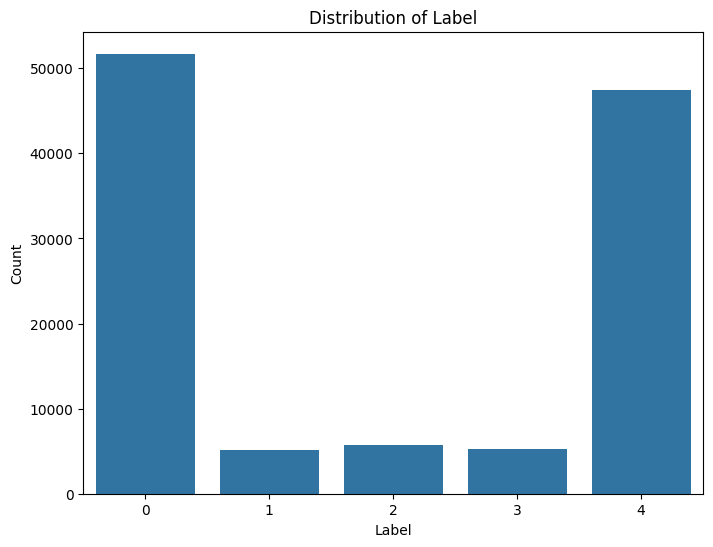

In [160]:
# Count plot for the 'label' column
plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=final_model_df)
plt.title("Distribution of Label")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

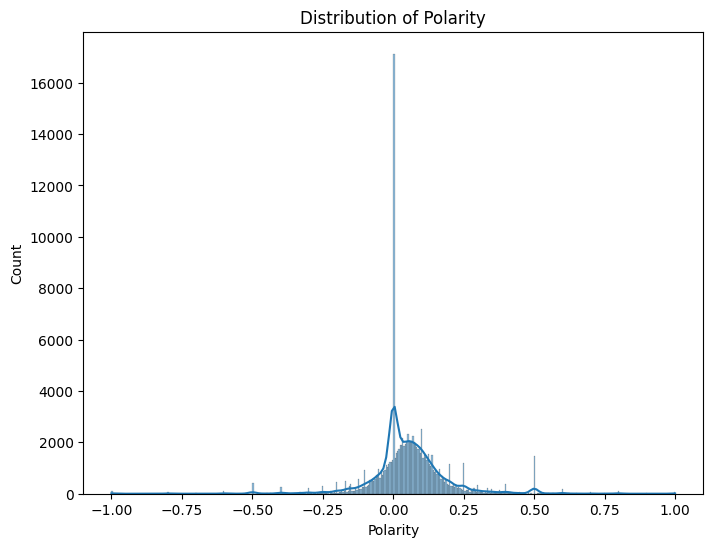

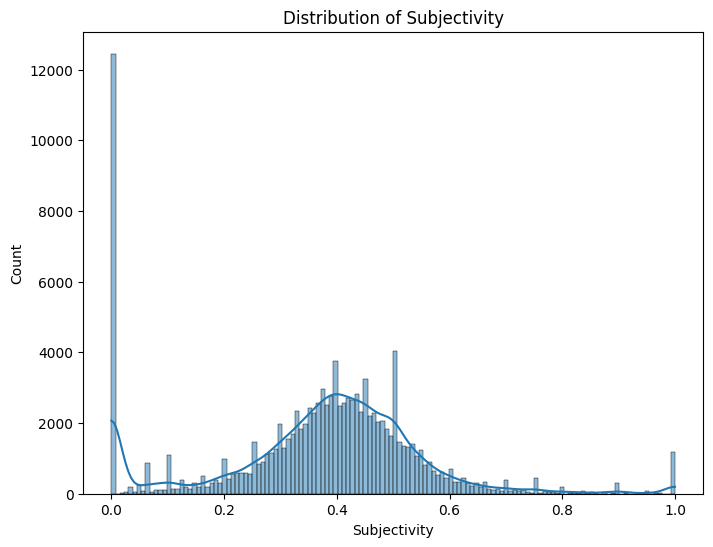

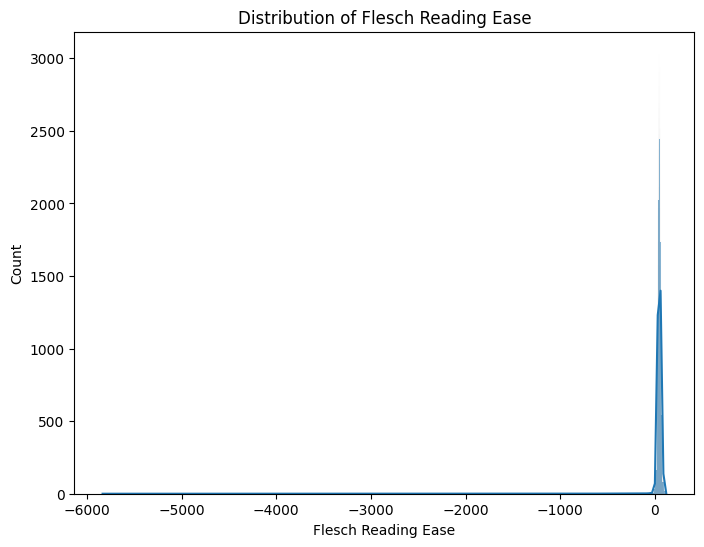

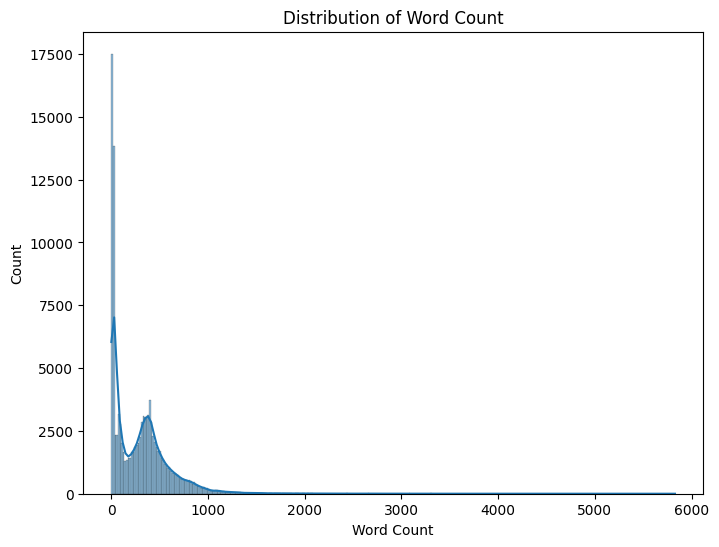

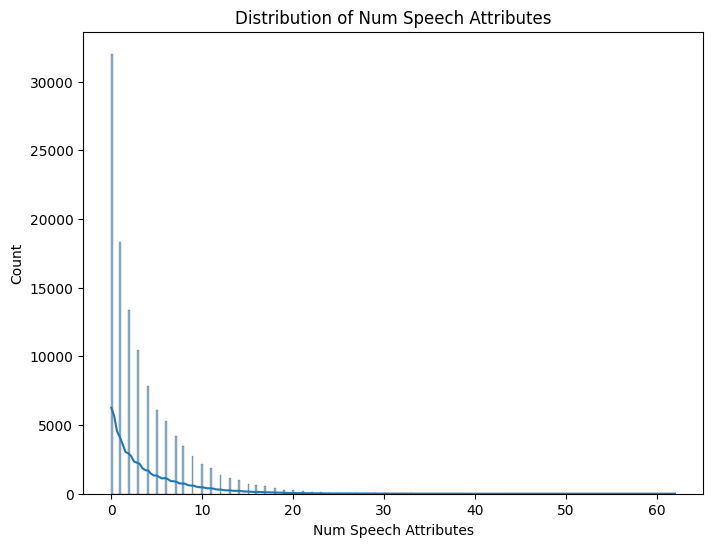

In [164]:
# Histogram and KDE for Polarity
plt.figure(figsize=(8, 6))
sns.histplot(final_model_df['overall_polarity'], kde=True)
plt.title("Distribution of Polarity")
plt.xlabel("Polarity")
plt.show()

# Histogram and KDE for Subjectivity 
# TODO - Check out avg subjectivity score and look into the massive 0 values
plt.figure(figsize=(8, 6))
sns.histplot(final_model_df['overall_subjectivity'], kde=True)
plt.title("Distribution of Subjectivity")
plt.xlabel("Subjectivity")
plt.show()

# Histogram and KDE for Flesch Reading Ease
plt.figure(figsize=(8, 6))
sns.histplot(final_model_df['flesch_reading_ease'], kde=True)
plt.title("Distribution of Flesch Reading Ease")
plt.xlabel("Flesch Reading Ease")
plt.show()

# Histogram and KDE for word count
plt.figure(figsize=(8, 6))
sns.histplot(final_model_df['word_count'], kde=True)
plt.title("Distribution of Word Count")
plt.xlabel("Word Count")
plt.show()

# Histogram and KDE for num speech attributes
plt.figure(figsize=(8, 6))
sns.histplot(final_model_df['num_speech_attributes'], kde=True)
plt.title("Distribution of Num Speech Attributes")
plt.xlabel("Num Speech Attributes")
plt.show()

# Correlation Heatmap for numeric features
# Dimensionality Reduction needs to be performed before plotting the heatmap
# plt.figure(figsize=(12, 10))
# numeric_cols = eda_df.select_dtypes(include=['int64', 'float64']).columns
# corr = eda_df[numeric_cols].corr()
# sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
# plt.title("Correlation Heatmap of Numeric Features")
# plt.show()


## Train using the best model from before

In [ ]:
# Due to the imbalance in labels and the inherent difficulty with producing a "credibility rating" 
# for a news article, I'll transform the labels into a binary classification problem.
# Define the mapping: original labels 0,1,2 become 0; 3 and 4 become 4. Original scale was 0 = Fake News, 4 = True News
mapping = {0: 0, 1: 0, 2: 0, 3: 4, 4: 4}

# Apply the mapping to the label column (if they are already numeric or can be converted to numeric)
final_model_df['binary_label'] = final_model_df['label'].apply(lambda x: mapping.get(int(x), None))

# convert binary_label to a more intuitive binary format:
final_model_df['binary_label'] = final_model_df['binary_label'].replace({0: 0, 4: 1})


In [166]:
# Create x and y variables
X = final_model_df.drop(columns=['Unnamed: 0', 'label', 'text', 'features', 'binary_label'])
y = final_model_df['binary_label']

# Split the data into training and testing sets using stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=24, stratify=y
)

In [167]:
rf = RandomForestClassifier(random_state=24)

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 4, 6],
    'max_features': ['sqrt', 'log2', None]
}

scoring = {
    'accuracy': 'accuracy',
    'f1_score': 'f1'
}

grid_rf = GridSearchCV(
    rf, 
    param_grid_rf, 
    cv=5, 
    scoring=scoring,
    refit='accuracy', 
    n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Best parameters (Random Forest):", grid_rf.best_params_)
print("Best CV score (Random Forest):", grid_rf.best_score_)

Best parameters (Random Forest): {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV score (Random Forest): 0.937070302745567


In [168]:
import joblib

# Assuming grid_rf is your GridSearchCV object:
best_rf_model = grid_rf.best_estimator_

# Save the best model to disk
joblib.dump(best_rf_model, 'best_rf_model.pkl')
print("Model saved to best_rf_model.pkl")


Model saved to best_rf_model.pkl


# Example of loading and using the model

In [170]:
loaded_rf_model = joblib.load('data/best_rf_model.pkl')

In [ ]:
loaded_rf_model.p

RandomForestClassifier(max_features='log2', min_samples_leaf=2,
                       min_samples_split=5, n_estimators=200, random_state=24)